In [5]:
import geopandas as gpd

# 读取全伦敦的CID停车点数据(19MB,读取可能要几秒)
cid = gpd.read_file("/Users/wusiyi/Documents/CASA/dis/DATA/cycle_parking.json")

print(cid.crs)          # 检查坐标系
print(cid.shape)        # 看一下总共多少条记录
print(cid.columns.tolist())
print(cid.head())

EPSG:4326
(23758, 22)
['FEATURE_ID', 'SVDATE', 'PRK_CARR', 'PRK_COVER', 'PRK_SECURE', 'PRK_LOCKER', 'PRK_SHEFF', 'PRK_MSTAND', 'PRK_PSTAND', 'PRK_HOOP', 'PRK_POST', 'PRK_BUTERF', 'PRK_WHEEL', 'PRK_HANGAR', 'PRK_TIER', 'PRK_OTHER', 'PRK_PROVIS', 'PRK_CPT', 'BOROUGH', 'PHOTO1_URL', 'PHOTO2_URL', 'geometry']
  FEATURE_ID     SVDATE PRK_CARR PRK_COVER PRK_SECURE PRK_LOCKER PRK_SHEFF  \
0  RWG014703 2017-09-07    FALSE     FALSE      FALSE      FALSE     FALSE   
1  RWG014704 2017-09-07    FALSE     FALSE      FALSE      FALSE     FALSE   
2  RWG014970 2017-06-20    FALSE     FALSE      FALSE      FALSE      TRUE   
3  RWG015506 2017-06-24    FALSE     FALSE      FALSE      FALSE      TRUE   
4  RWG015513 2017-09-07    FALSE     FALSE      FALSE      FALSE      TRUE   

  PRK_MSTAND PRK_PSTAND PRK_HOOP  ... PRK_WHEEL PRK_HANGAR PRK_TIER PRK_OTHER  \
0      FALSE      FALSE    FALSE  ...     FALSE       TRUE    FALSE     FALSE   
1      FALSE      FALSE    FALSE  ...     FALSE       TRUE    

In [7]:
westminster = cid[cid['BOROUGH'] == 'Westminster']
print(len(westminster))

1603


In [8]:
cid['BOROUGH'].unique()

array(['Hammersmith & Fulham', 'Kensington & Chelsea', 'Westminster',
       'Camden', 'Hackney', 'Islington', 'City of London',
       'Tower Hamlets', 'Lambeth', 'Wandsworth', 'Southwark', 'Havering',
       'Enfield', 'Waltham Forest', 'Richmond upon Thames',
       'Kingston upon Thames', 'Merton', 'Hounslow', 'Barking & Dagenham',
       'Greenwich', 'Sutton', 'Newham', 'Bexley', 'Redbridge', 'Bromley',
       'Lewisham', 'Croydon', 'Brent', 'Ealing', 'Hillingdon', 'Harrow',
       'Barnet', 'Haringey'], dtype=object)

In [11]:
soho_boundary = gpd.read_file("/Users/wusiyi/Documents/CASA/dis/DATA/raw/soho_boundary.geojson")

# 统一坐标系,CID数据是EPSG:4326
soho_boundary = soho_boundary.to_crs(cid.crs)

cid_soho = gpd.clip(westminster, soho_boundary)
print(f"Soho范围内共有 {len(cid_soho)} 个自行车停车点")

# 保存结果
cid_soho.to_file(
    "/Users/wusiyi/Documents/CASA/dis/DATA/raw/soho_cycle_parking.geojson", 
    driver="GeoJSON"
)

Soho范围内共有 89 个自行车停车点


<Axes: >

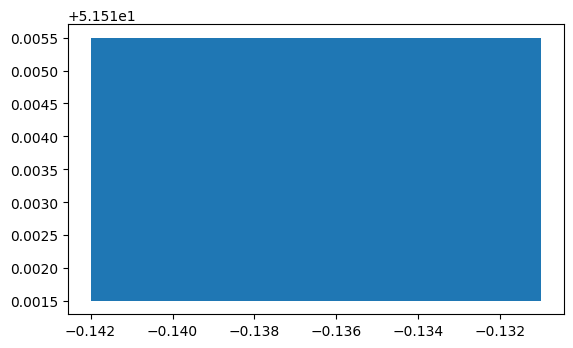

In [10]:
from shapely.geometry import box
import geopandas as gpd

# 用你已经定义好的边界坐标(不加buffer,buffer是为了让路网提取更完整,边界本身不需要buffer)
north, south, east, west = 51.5155, 51.5115, -0.1310, -0.1420

soho_boundary_geom = box(west, south, east, north)  # shapely.geometry.box(minx, miny, maxx, maxy)

soho_boundary = gpd.GeoDataFrame(
    {"name": ["Soho"]}, 
    geometry=[soho_boundary_geom], 
    crs="EPSG:4326"
)

soho_boundary.to_file(
    "/Users/wusiyi/Documents/CASA/dis/DATA/raw/soho_boundary.geojson", 
    driver="GeoJSON"
)

soho_boundary.plot()

/Users/wusiyi/.venvs/group_work_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 33258 (\N{CJK UNIFIED IDEOGRAPH-81EA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/wusiyi/.venvs/group_work_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/wusiyi/.venvs/group_work_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36710 (\N{CJK UNIFIED IDEOGRAPH-8F66}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/wusiyi/.venvs/group_work_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20572 (\N{CJK UNIFIED IDEOGRAPH-505C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/wusiyi/.venvs/group_work_env/lib/python3.12/site-packages/IPython/cor

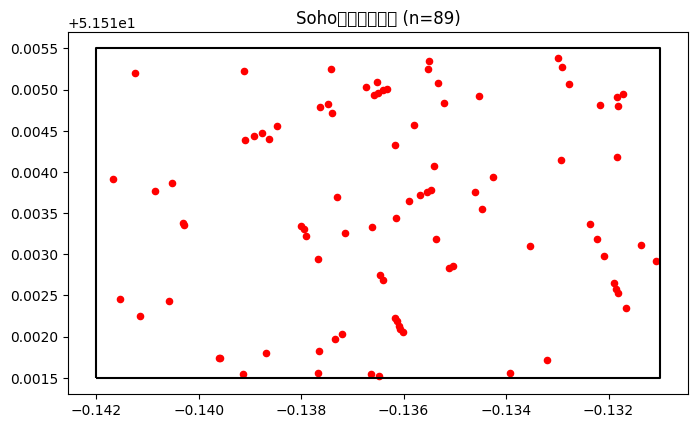

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))
soho_boundary.boundary.plot(ax=ax, color='black')
cid_soho.plot(ax=ax, color='red', markersize=20)
plt.title(f"Soho自行车停车点 (n={len(cid_soho)})")
plt.show()